In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if '.' not in sys.path:
    sys.path.insert(0, '.')
os.makedirs('images', exist_ok=True)

In [2]:
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import tensorflow as tf

from estimator.QIS          import QIS_batched_numpy
from estimator.pairwise_psd import pairwise_psd, pairwise_corr_np
from estimator.poet         import poet_from_corr
from estimator.nls          import lw_corr
from models.gru_denoiser    import BiGRUSpectralDenoiserTensorFlow

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
np.random.seed(42)
tf.random.set_seed(42)

## 1  Training

lancer entrenement sur bcp plus de batch, moins de bruits

In [3]:
import os
if not os.path.exists('models/bigru_weights_realdata.weights.h5'):
    !.venv/bin/python scripts/train_realdata.py 2>&1
else:
    print("Skipping training — using existing weights")

Skipping training — using existing weights


In [4]:
model = BiGRUSpectralDenoiserTensorFlow(hidden_size=64)
model(tf.zeros((1, 80, 5)))   # build weights; model is N-agnostic, 5-feature input
model.load_weights('models/bigru_weights_realdata.weights.h5')
print(f'Parameters: {model.count_params():,}')

Parameters: 27,393


## 2  Load real data

In [5]:
DATA = 'data/vanilla_returns_top_3000_with_NaN_dtin_max_1200.joblib'

print('Loading data…')
bundle   = joblib.load(DATA, mmap_mode='r')
ret_df   = bundle.returns.copy()
avail_df = bundle.available_stocks.copy()
ret_df.index   = pd.to_datetime(ret_df.index)
avail_df.index = pd.to_datetime(avail_df.index)

is_num = pd.api.types.is_numeric_dtype(ret_df.columns)
codes, unique_ids = pd.factorize(avail_df.to_numpy().ravel())
if is_num:
    unique_ids = pd.to_numeric(unique_ids)
else:
    ret_df.columns = ret_df.columns.astype(str)
    unique_ids = unique_ids.astype(str)

avail_codes  = codes.reshape(avail_df.shape)
ret_mat      = ret_df.reindex(columns=unique_ids).values
avail_to_ret = ret_df.index.get_indexer(avail_df.index)
assert (avail_to_ret >= 0).all()
n_avail = avail_codes.shape[0]
print(f'  returns {ret_mat.shape}  avail {avail_codes.shape}')

Loading data…
  returns (8817, 13291)  avail (7551, 3000)


## 3  Q-sweep benchmark — micro-cap with missingness

Same structure as `comparison_realdata_nomiss.ipynb`: N=100, Q_VALUES=[0.3…3.0], N_STEPS=240,
metric = realized min-variance portfolio variance.  Data source: micro-cap stocks (ranks 2500–3000)
which have genuine IPO-driven missingness.

**Estimators:**
- **Sample**: pairwise MLE correlation (NaN-aware)
- **LW**: Ledoit-Wolf shrinkage on the synchronous sub-window
- **QIS**: analytical shrinkage on the synchronous sub-window
- **POET**: factor cleaning on the pairwise-PSD matrix
- **NN**: miss BiGRU (this work)

In [15]:
Q_VALUES  = [0.3, 0.5, 0.7, 0.95, 1.2, 1.5, 2.0, 2.5]  # same as no-miss
N_STEPS   = 240
T_OOS     = 5
N         = 100   # same as no-miss
MICRO_CAP = slice(2500, 3000)

In [16]:
def sample_corr(R):
    Rc = R - R.mean(axis=1, keepdims=True)
    S  = Rc @ Rc.T / (R.shape[1] - 1)
    d  = np.sqrt(np.maximum(np.diag(S), 1e-12))
    C  = S / np.outer(d, d)
    np.fill_diagonal(C, 1.0)
    return 0.5 * (C + C.T)


def min_var_lvar(C, R_oos):
    N_ = C.shape[0]
    ones = np.ones((N_, 1))
    try:
        x = np.linalg.solve(C + 1e-6 * np.eye(N_), ones)
        s = float(x.sum())
        if abs(s) < 1e-8:   # degenerate weights — fall back to equal-weight
            w = ones / N_
        else:
            w = x / s
    except np.linalg.LinAlgError:
        w = ones / N_
    return float(np.mean((R_oos.T @ w) ** 2))


def make_input_seq_miss(R_nan, N_, T_):
    nan_mask = np.isnan(R_nan)
    nan_mask[:, 1:] |= nan_mask[:, :-1]      # bad_next: match training pipeline
    observed = ~nan_mask
    C_pair = pairwise_corr_np(np.where(nan_mask, np.nan, R_nan))
    C_pair = np.where(np.isfinite(C_pair), C_pair, 0.0)
    np.fill_diagonal(C_pair, 1.0)
    C_pair = 0.5 * (C_pair + C_pair.T) + 1e-6 * np.eye(N_)
    eigvals, eigvecs = np.linalg.eigh(C_pair)
    lam = eigvals.astype(np.float32)
    pos = np.linspace(0.0, 1.0, N_, dtype=np.float32)
    has_any  = observed.any(axis=1)
    t_first  = np.argmax(observed, axis=1).astype(np.float32) / T_
    t_first  = np.where(has_any, t_first, 1.0)
    Tminmean = (eigvecs ** 2).T @ t_first
    eff_T    = np.maximum(1.0 - Tminmean, 1.0 / T_)
    q_eff    = (N_ / T_) / eff_T
    ipr      = (N_ * np.sum(eigvecs ** 4, axis=0)).astype(np.float32)
    q_s      = np.maximum(q_eff, 1e-6).astype(np.float32)
    z_mp     = (lam - (1.0 + np.sqrt(q_s)) ** 2) / np.sqrt(q_s)
    inp      = np.stack([lam, pos, q_eff.astype(np.float32), ipr, z_mp], axis=1)
    return tf.constant(inp[None], dtype=tf.float32), eigvecs


def run_nn(R_nan, N_, T_):
    try:
        inp, Q_e = make_input_seq_miss(R_nan, N_, T_)
        lam = np.maximum(model(inp, training=False)[0].numpy(), 1e-4)
        C_nn = Q_e @ np.diag(lam) @ Q_e.T
        return 0.5 * (C_nn + C_nn.T)
    except Exception:
        return None

In [17]:
NAMES = ['Sample', 'LW', 'QIS', 'POET', 'NN']
n_est = len(NAMES)
lvar  = np.full((len(Q_VALUES), N_STEPS, n_est), np.nan)
rng   = np.random.default_rng(42)

for qi, q in enumerate(Q_VALUES):
    T_in = int(N / q)
    print(f'\nq={q:.2f}  T_in={T_in}')

    step = 0; attempts = 0
    while step < N_STEPS and attempts < 5000:
        attempts += 1
        t_anchor     = rng.integers(T_in - 1, n_avail - T_OOS - 1)
        t0           = t_anchor - T_in + 1
        codes_anchor = avail_codes[t_anchor, MICRO_CAP]
        ret_rows     = avail_to_ret[t0: t0 + T_in + T_OOS]
        if (ret_rows < 0).any():
            continue
        R_cap     = ret_mat[np.ix_(ret_rows, codes_anchor)]
        R_oos_raw = R_cap[T_in:, :]
        oos_ok    = np.isfinite(R_oos_raw).all(axis=0)
        if oos_ok.sum() < N:
            continue
        chosen = rng.choice(np.where(oos_ok)[0], N, replace=False)
        R_base = R_cap[:T_in,  chosen].T.astype(np.float64)   # (N, T_in) with NaN at missing
        R_oos  = R_oos_raw[:, chosen].T.astype(np.float64)    # (N, T_OOS)

        # per-stock z-score using observed values only
        obs  = np.isfinite(R_base)
        cnt  = obs.sum(axis=1, keepdims=True).clip(min=1)
        mu   = np.where(obs, R_base, 0.0).sum(axis=1, keepdims=True) / cnt
        sq   = np.where(obs, (R_base - mu) ** 2, 0.0)
        sig  = np.sqrt(sq.sum(axis=1, keepdims=True) / np.maximum(cnt - 1, 1)).clip(min=1e-8)
        R_z  = np.where(obs, (R_base - mu) / sig, np.nan)     # NaN at missing

        sync   = obs.all(axis=0)                               # (T_in,) fully-observed timesteps
        T_sync = int(sync.sum())
        R_sync = R_z[:, sync]                                  # (N, T_sync)

        # Sample — pairwise MLE
        try:
            C_pair = pairwise_corr_np(R_z)
            C_pair = np.where(np.isfinite(C_pair), C_pair, 0.0)
            np.fill_diagonal(C_pair, 1.0)
            C_pair = 0.5 * (C_pair + C_pair.T) + 1e-4 * np.eye(N)
            lvar[qi, step, 0] = min_var_lvar(C_pair, R_oos)
        except Exception:
            pass

        # LW — synchronous window
        try:
            if T_sync >= 2:
                lvar[qi, step, 1] = min_var_lvar(lw_corr(R_sync), R_oos)
        except Exception:
            pass

        # QIS — synchronous window
        try:
            if T_sync >= 2:
                Sv  = QIS_batched_numpy(R_sync[None])[0]
                d   = np.sqrt(np.maximum(np.diag(Sv), 1e-12))
                C_q = Sv / np.outer(d, d)
                np.fill_diagonal(C_q, 1.0)
                lvar[qi, step, 2] = min_var_lvar(0.5 * (C_q + C_q.T), R_oos)
        except Exception:
            pass

        # POET — pairwise PSD
        try:
            C_psd  = pairwise_psd(R_z)
            t_eff  = int(np.median(obs.sum(axis=1)))
            C_poet = poet_from_corr(C_psd, T_eff=t_eff, K=3)
            lvar[qi, step, 3] = min_var_lvar(C_poet, R_oos)
        except Exception:
            pass

        # NN
        try:
            C_nn = run_nn(R_base, N, T_in)
            if C_nn is not None:
                lvar[qi, step, 4] = min_var_lvar(C_nn, R_oos)
        except Exception:
            pass

        step += 1
        if step % 20 == 0:
            print(f'  {step}/{N_STEPS}', flush=True)

print('Done.')


q=0.30  T_in=333
  20/240
  40/240
  60/240
  80/240
  100/240
  120/240
  140/240
  160/240
  180/240
  200/240
  220/240
  240/240

q=0.50  T_in=200
  20/240
  40/240
  60/240
  80/240
  100/240
  120/240
  140/240
  160/240
  180/240
  200/240
  220/240
  240/240

q=0.70  T_in=142
  20/240
  40/240
  60/240
  80/240
  100/240
  120/240
  140/240
  160/240
  180/240
  200/240
  220/240
  240/240

q=0.95  T_in=105
  20/240
  40/240
  60/240
  80/240
  100/240
  120/240
  140/240
  160/240
  180/240
  200/240
  220/240
  240/240

q=1.20  T_in=83
  20/240
  40/240
  60/240
  80/240
  100/240
  120/240
  140/240
  160/240
  180/240
  200/240
  220/240
  240/240

q=1.50  T_in=66
  20/240
  40/240
  60/240
  80/240
  100/240
  120/240
  140/240
  160/240
  180/240
  200/240
  220/240
  240/240

q=2.00  T_in=50
  20/240
  40/240
  60/240
  80/240
  100/240
  120/240
  140/240
  160/240
  180/240
  200/240
  220/240
  240/240

q=2.50  T_in=40
  20/240
  40/240
  60/240
  80/240
  100/240
  

## 4  Results table

In [18]:
means = np.nanmean(lvar, axis=1)   # (Q, 5)

print('   ' + '  '.join(f'{n:>10}' for n in NAMES))
print('=' * 65)
for qi, q in enumerate(Q_VALUES):
    row  = means[qi]
    best = int(np.nanargmin(row))
    vals = '  '.join(
        f'{v:10.5f}{"*" if i == best else " "}' for i, v in enumerate(row)
    )
    print(f'q={q:.2f}  {vals}')
print('=' * 65)
print('Mean ' + '  '.join(f'{np.nanmean(lvar[:, :, i]):10.5f} ' for i in range(n_est)))

       Sample          LW         QIS        POET          NN
q=0.30     0.07778      0.00029      0.00029      0.00025      0.00023*
q=0.50     0.01807      0.00026      0.00029      0.00026      0.00024*
q=0.70     0.01439      0.00022      0.00021      0.00021      0.00019*
q=0.95     0.51888      0.00023      0.00024      0.00018*     0.00019 
q=1.20     0.00106      0.00026      0.00022      0.00023      0.00021*
q=1.50     0.00045      0.00022      0.00020      0.00021      0.00018*
q=2.00     0.00043      0.00028      0.00028      0.00028      0.00026*
q=2.50     0.00035      0.00026      0.00025      0.00025      0.00024*
Mean    0.07893      0.00025      0.00025      0.00023      0.00022 


## 5  Q-curve

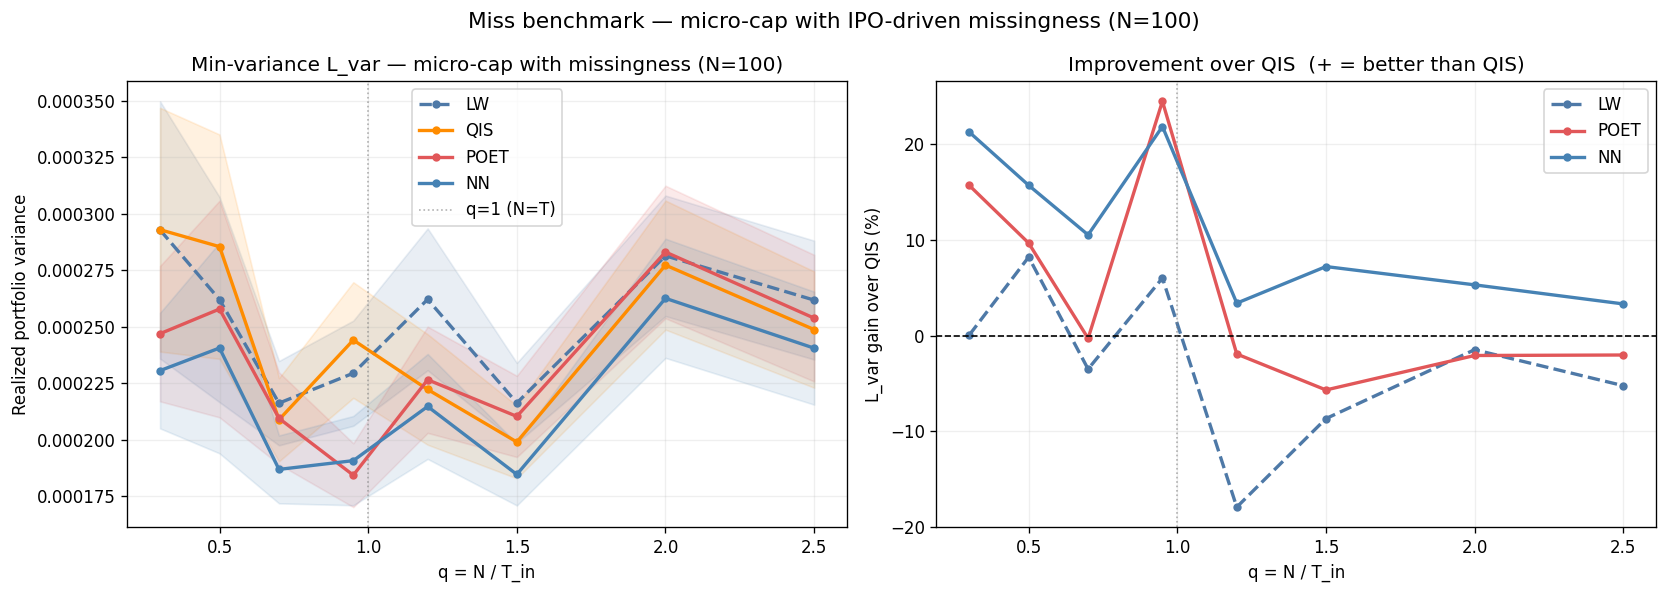

In [19]:
qs = np.array(Q_VALUES)
COLORS = {
    'Sample': ('dimgrey',    '-'),
    'LW':     ('#4e79a7',   '--'),
    'QIS':    ('darkorange', '-'),
    'POET':   ('#e15759',    '-'),
    'NN':     ('steelblue',  '-'),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, name in enumerate(NAMES):
    if name == 'Sample':   # non-PSD → pathological MVP weights → off-scale variance
        continue
    color, ls = COLORS[name]
    y = np.nanmean(lvar[:, :, i], axis=1)
    s = np.nanstd(lvar[:, :, i],  axis=1) / np.sqrt(N_STEPS)
    ok = np.isfinite(y)
    ax1.plot(qs[ok], y[ok], color=color, ls=ls, lw=2, marker='o', ms=4, label=name)
    ax1.fill_between(qs[ok], (y - s)[ok], (y + s)[ok], alpha=0.12, color=color)

ax1.axvline(1, color='grey', lw=1, ls=':', alpha=0.6, label='q=1 (N=T)')
ax1.set_xlabel('q = N / T_in')
ax1.set_ylabel('Realized portfolio variance')
ax1.set_title('Min-variance L_var — micro-cap with missingness (N=100)')
ax1.legend()
ax1.grid(alpha=0.2)

qis_i = NAMES.index('QIS')
for i, name in enumerate(NAMES):
    if name in ('QIS', 'Sample'):
        continue
    color, ls = COLORS[name]
    y_est = np.nanmean(lvar[:, :, i],     axis=1)
    y_qis = np.nanmean(lvar[:, :, qis_i], axis=1)
    gain  = (y_qis - y_est) / y_qis * 100
    ok    = np.isfinite(gain)
    ax2.plot(qs[ok], gain[ok], color=color, ls=ls, lw=2, marker='o', ms=4, label=name)

ax2.axhline(0, color='black', lw=1, ls='--')
ax2.axvline(1, color='grey',  lw=1, ls=':', alpha=0.6)
ax2.set_xlabel('q = N / T_in')
ax2.set_ylabel('L_var gain over QIS (%)')
ax2.set_title('Improvement over QIS  (+ = better than QIS)')
ax2.legend()
ax2.grid(alpha=0.2)

plt.suptitle('Miss benchmark — micro-cap with IPO-driven missingness (N=100)', fontsize=13)
plt.tight_layout()
plt.savefig('images/realdata_miss_qcurve.png', dpi=150)
plt.show()

## 6  Gain over QIS — numerical breakdown

In [20]:
competitors = [n for n in NAMES if n not in ('QIS', 'Sample')]
print('   ' + '  '.join(f'{n:>14}' for n in competitors))
print('=' * (4 + 16 * len(competitors)))
for qi, q in enumerate(Q_VALUES):
    y_qis = np.nanmean(lvar[qi, :, qis_i])
    vals = []
    for name in competitors:
        i = NAMES.index(name)
        y_est = np.nanmean(lvar[qi, :, i])
        gain  = (y_qis - y_est) / y_qis * 100
        vals.append(f'{gain:+14.1f}%')
    print(f'q={q:.1f}  ' + '  '.join(vals))

# also show absolute NN vs QIS
print()
print('NN vs QIS (absolute):')
nn_i = NAMES.index('NN')
for qi, q in enumerate(Q_VALUES):
    qis_v = np.nanmean(lvar[qi, :, qis_i])
    nn_v  = np.nanmean(lvar[qi, :, nn_i])
    gain  = (qis_v - nn_v) / qis_v * 100
    marker = '  ← NN wins' if gain > 5 else ('  ← QIS wins' if gain < -5 else '  ≈ tied')
    print(f'  q={q:.1f}  QIS={qis_v:.5f}  NN={nn_v:.5f}  {gain:+.1f}%{marker}')

               LW            POET              NN
q=0.3            +0.0%           +15.7%           +21.3%
q=0.5            +8.2%            +9.7%           +15.7%
q=0.7            -3.5%            -0.3%           +10.5%
q=0.9            +6.0%           +24.5%           +21.9%
q=1.2           -18.0%            -1.9%            +3.4%
q=1.5            -8.7%            -5.7%            +7.2%
q=2.0            -1.5%            -2.1%            +5.3%
q=2.5            -5.3%            -2.0%            +3.3%

NN vs QIS (absolute):
  q=0.3  QIS=0.00029  NN=0.00023  +21.3%  ← NN wins
  q=0.5  QIS=0.00029  NN=0.00024  +15.7%  ← NN wins
  q=0.7  QIS=0.00021  NN=0.00019  +10.5%  ← NN wins
  q=0.9  QIS=0.00024  NN=0.00019  +21.9%  ← NN wins
  q=1.2  QIS=0.00022  NN=0.00021  +3.4%  ≈ tied
  q=1.5  QIS=0.00020  NN=0.00018  +7.2%  ← NN wins
  q=2.0  QIS=0.00028  NN=0.00026  +5.3%  ← NN wins
  q=2.5  QIS=0.00025  NN=0.00024  +3.3%  ≈ tied
